In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
dfh = pd.read_csv('../../data/scored_profiles_shuffled.csv')
dfh = dfh[:20000]
dfr = pd.read_csv('../../data/scored_real_profiles.csv')
df_probm = pd.concat([dfh,dfr])
col_scores = ['Logistic_regression_score', 'LogitSquare', 
       'adplasso_interaction_thres0.0001','adplasso_square_thres0.0001',
       'adplasso_interaction_square_thres0.0001','MLP_score',
       'MLP_attention_score', 
       'XGBoost']
col_probs = [f'pr_{col}' for col in col_scores]
df_probm = df_probm[['profile_id', 'battery life (in hours of video playback)', 'screen size (in inches)',
       'thickness (in mm)', 'front camera resolution (in MP)',
       'rear camera main lens resolution (in MP)',
       'rear camera longest focal length (in x)', 'ultrawide camera',
       'Geekbench multicore score', 'RAM', 'price']+col_scores]

In [42]:
for col in col_scores:
    exp_scores = df_probm[col].apply(lambda x: np.exp(x)).values
    J = len(exp_scores)
    exp_j = exp_scores.reshape(-1, 1)   # (J,1)
    exp_k = exp_scores.reshape(1, -1)   # (1,J)

    P = exp_j / (exp_j + exp_k)         # (J,J)

    np.fill_diagonal(P, np.nan)
    pr_avg = np.nanmean(P, axis=1)

    df_probm["pr_"+col] = pr_avg
    print(col)
    now = datetime.now()
    formatted = now.strftime("%Y-%m-%d %H:%M:%S")
    print(formatted)

Logistic_regression_score
2026-04-25 17:39:47
LogitSquare
2026-04-25 17:39:50
adplasso_interaction_thres0.0001
2026-04-25 17:39:51
adplasso_square_thres0.0001
2026-04-25 17:39:53
adplasso_interaction_square_thres0.0001
2026-04-25 17:39:54
MLP_score
2026-04-25 17:39:56
MLP_attention_score
2026-04-25 17:39:58
XGBoost
2026-04-25 17:39:59


In [43]:
df_probm.to_csv('../../data/prob_method2_profiles.csv', index=False)
df_probm

,profile_id,battery life (in hours of video playback),screen size (in inches),thickness (in mm),front camera resolution (in MP),rear camera main lens resolution (in MP),rear camera longest focal length (in x),ultrawide camera,Geekbench multicore score,RAM,...,MLP_attention_score,XGBoost,pr_Logistic_regression_score,pr_LogitSquare,pr_adplasso_interaction_thres0.0001,pr_adplasso_square_thres0.0001,pr_adplasso_interaction_square_thres0.0001,pr_MLP_score,pr_MLP_attention_score,pr_XGBoost
0,0,25.0,6.3,8.78,30.0,36.0,5.0,equipped,8642.0,8,...,1.758439,0.727843,0.776121,0.813598,0.795198,0.845848,0.828838,0.820758,0.844799,0.663525
1,1,36.0,6.6,8.16,17.0,29.0,1.0,equipped,6119.0,4,...,0.709014,0.462179,0.822105,0.703231,0.847351,0.700300,0.706153,0.714129,0.725339,0.605463
2,2,24.0,6.9,8.80,18.0,34.0,10.0,equipped,7766.0,12,...,-0.366342,0.338729,0.722837,0.661551,0.749449,0.644538,0.658753,0.688184,0.577316,0.577387
3,3,20.0,6.6,8.80,13.0,72.0,1.0,not equipped,9698.0,4,...,-2.647426,-0.529528,0.411549,0.267695,0.385754,0.225803,0.261270,0.274261,0.263350,0.376546
4,4,43.0,6.3,7.70,12.0,38.0,4.9,equipped,9560.0,4,...,2.351568,0.787596,0.874602,0.898514,0.890190,0.916967,0.914207,0.885008,0.895195,0.676032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,iPhone 16 Pro Max,33.0,6.9,8.25,12.0,48.0,5.0,equipped,8504.0,8,...,3.082228,1.115534,0.764128,0.905445,0.786678,0.910390,0.918942,0.937978,0.939509,0.740226
4,iPhone 17,30.0,6.3,7.95,18.0,48.0,2.0,equipped,9000.0,8,...,3.197376,1.002214,0.802864,0.905993,0.827416,0.921531,0.923662,0.916967,0.944865,0.718947
5,iPhone 17 Air,27.0,6.5,5.64,18.0,48.0,2.0,not equipped,9317.0,12,...,-1.522572,-0.222579,0.350824,0.362569,0.327861,0.360495,0.365179,0.367787,0.412942,0.446358
6,iPhone 17 Pro,33.0,6.3,8.75,18.0,48.0,8.0,equipped,9317.0,12,...,2.144119,0.756524,0.781349,0.875739,0.801898,0.889886,0.892126,0.889715,0.879084,0.669556


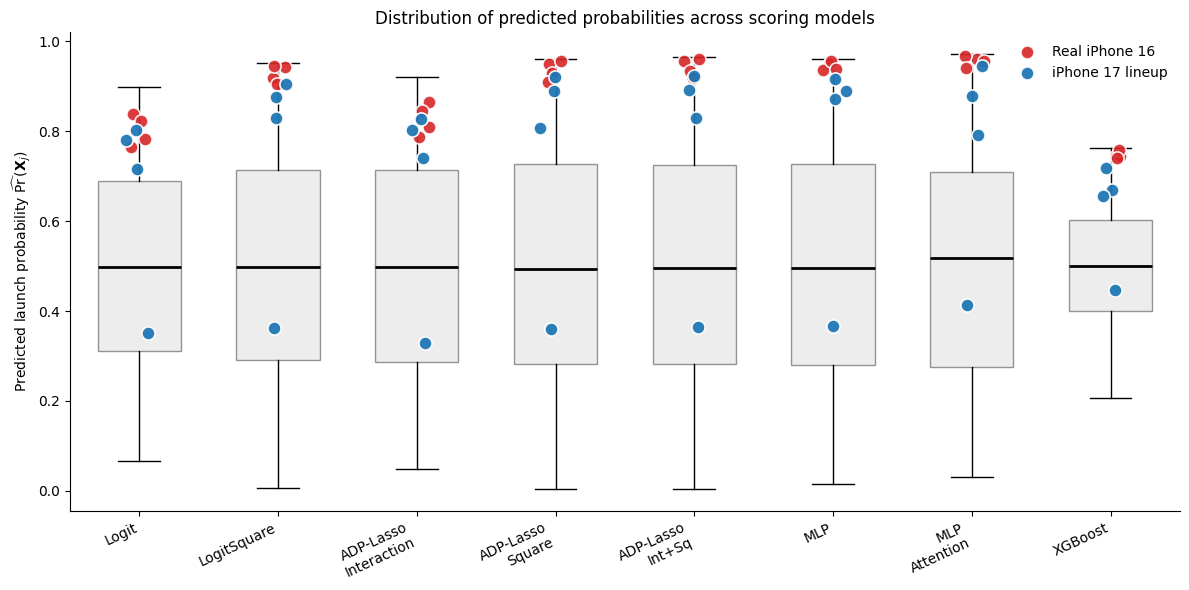

In [52]:
import matplotlib.pyplot as plt

plot_cols = col_probs
plot_data = [df_probm[col].dropna().values for col in plot_cols]

name_map = {
    "iPhone 16": "16 Std",
    "iPhone 16 Plus": "16 Plus",
    "iPhone 16 Pro": "16 Pro",
    "iPhone 16 Pro Max": "16 Pro Max",
}

real_df = df_probm[df_probm["profile_id"].isin(name_map)].copy()
real_df["label"] = real_df["profile_id"].map(name_map)

iphone17_name_map = {
    "iPhone 17": "17 Std",
    "iPhone 17 Air": "17 Air",
    "iPhone 17 Pro": "17 Pro",
    "iPhone 17 Pro Max": "17 Pro Max",
}
iphone17_df = df_probm[df_probm["profile_id"].isin(iphone17_name_map)].copy()
iphone17_df["label"] = iphone17_df["profile_id"].map(iphone17_name_map)

display_name_map = {
    "pr_Logistic_regression_score": "Logit",
    "pr_LogitSquare": "LogitSquare",
    "pr_adplasso_interaction_thres0.0001": "ADP-Lasso\nInteraction",
    "pr_adplasso_square_thres0.0001": "ADP-Lasso\nSquare",
    "pr_adplasso_interaction_square_thres0.0001": "ADP-Lasso\nInt+Sq",
    "pr_MLP_score": "MLP",
    "pr_MLP_attention_score": "MLP\nAttention",
    "pr_XGBoost": "XGBoost",
}
xpos = np.arange(1, len(plot_cols) + 1)

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(
    plot_data,
    positions=xpos,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set(facecolor="#D3D3D3", alpha=0.4, edgecolor="black")

for median in bp["medians"]:
    median.set(color="black", linewidth=2)

np.random.seed(123)
for i, col in enumerate(plot_cols, start=1):
    x_jitter = i + np.random.normal(0, 0.04, size=len(real_df))
    ax.scatter(
        x_jitter,
        real_df[col],
        s=90,
        color="#D62728",
        edgecolor="white",
        linewidth=1.2,
        alpha=0.9,
        zorder=3,
        label="Real iPhone 16" if i == 1 else None,
    )

    # for x, y, label in zip(x_jitter, real_df[col], real_df["label"]):
    #     ax.text(x + 0.03, y, label, fontsize=8, va="center")

    if not iphone17_df.empty:
        x_17 = i + np.random.normal(0, 0.04, size=len(iphone17_df))
        ax.scatter(
            x_17,
            iphone17_df[col],
            s=90,
            color="#1F77B4",
            edgecolor="white",
            linewidth=1.2,
            alpha=0.95,
            zorder=4,
            label="iPhone 17 lineup" if i == 1 else None,
        )

        # for x, y, label in zip(x_17, iphone17_df[col], iphone17_df["label"]):
        #     ax.text(x + 0.03, y, label, fontsize=8, va="center", color="#1F77B4")

ax.set_ylabel(r"Predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$")
ax.set_xticks(xpos)
ax.set_xticklabels([display_name_map.get(col, col.replace("pr_", "")) for col in plot_cols], rotation=25, ha="right")
ax.set_title("Distribution of predicted probabilities across scoring models")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper right", frameon=False) #, bbox_to_anchor=(1.1, 1)

plt.tight_layout()
plt.show()

In [54]:
import pandas as pd
import numpy as np

# 如果你前面已经有 df_probm，就把下面这行删掉
df = pd.read_csv("../../data/prob_method2_profiles.csv").copy()

# 8 个真实产品
product_order = [
    "iPhone 16",
    "iPhone 16 Plus",
    "iPhone 16 Pro",
    "iPhone 16 Pro Max",
    "iPhone 17",
    "iPhone 17 Air",
    "iPhone 17 Pro",
    "iPhone 17 Pro Max",
]

# Pr 列和显示名
pr_cols = [
    "pr_Logistic_regression_score",
    "pr_LogitSquare",
    "pr_adplasso_interaction_thres0.0001",
    "pr_adplasso_square_thres0.0001",
    "pr_adplasso_interaction_square_thres0.0001",
    "pr_MLP_score",
    "pr_MLP_attention_score",
    "pr_XGBoost",
]

latex_col_names = [
    "-", "X$^{2}$", "Inter", "X$^{2}$", "Inter+$X^{2}$", "MLP", "MLP Attn", "XGBoost"
]

# percentile: 有多少样本不高于它
for col in pr_cols:
    vals = df[col]
    df[col + "_pct"] = vals.rank(method="average", pct=True) * 100

real_df = (
    df[df["profile_id"].isin(product_order)]
    .copy()
    .set_index("profile_id")
    .loc[product_order]
)

# 只保留 percentile，并格式化
pct_cols = [c + "_pct" for c in pr_cols]
table_df = real_df[pct_cols].copy()
table_df.columns = latex_col_names
table_df = table_df.map(lambda x: f"{x:.2f}")

# 拼 LaTeX
lines = []
lines.append(r"\begin{table}[h]")
lines.append(r"    \centering")
lines.append(r"    \begin{threeparttable}")
lines.append(r"        \caption{Actual profiles' relative rank under different models}")
lines.append(r"        \begin{tabular}{lcccccccc}")
lines.append(r"            \toprule")
lines.append(r"                                    & \multicolumn{2}{c}{Linear} & \multicolumn{3}{c}{Adaptive Lasso} & \multicolumn{3}{c}{Nonlinear} \\")
lines.append(r"            \cmidrule(lr){2-3}\cmidrule(lr){4-6}\cmidrule(lr){7-9}")
lines.append(r"            Top \% & - & $X^{2}$ & Inter & $X^{2}$ & Inter+$X^{2}$ & MLP & MLP Attn & XGBoost \\")
lines.append(r"            \midrule")

for idx, row in table_df.iterrows():
    row_str = " & ".join([idx] + row.tolist()) + r" \\"
    lines.append("            " + row_str)

lines.append(r"            \bottomrule")
lines.append(r"        \end{tabular}")
lines.append(r"        \begin{tablenotes}")
lines.append(r"            \small")
lines.append(r"            \item[a] Entries report percentile ranks based on predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$. Larger values indicate higher relative ranking among all profiles.")
lines.append(r"            \item[b] $X^{2}$ and Inter denote quadratic and interaction terms respectively.")
lines.append(r"            \item[c] MLP Attn denotes Attention-Based MLP.")
lines.append(r"        \end{tablenotes}")
lines.append(r"    \end{threeparttable}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)


\begin{table}[h]
    \centering
    \begin{threeparttable}
        \caption{Actual profiles' relative rank under different models}
        \begin{tabular}{lcccccccc}
            \toprule
                                    & \multicolumn{2}{c}{Linear} & \multicolumn{3}{c}{Adaptive Lasso} & \multicolumn{3}{c}{Nonlinear} \\
            \cmidrule(lr){2-3}\cmidrule(lr){4-6}\cmidrule(lr){7-9}
            Top \% & - & $X^{2}$ & Inter & $X^{2}$ & Inter+$X^{2}$ & MLP & MLP Attn & XGBoost \\
            \midrule
            iPhone 16 & 98.41 & 99.96 & 98.65 & 99.92 & 99.95 & 99.94 & 99.94 & 99.88 \\
            iPhone 16 Plus & 92.34 & 99.61 & 92.63 & 99.48 & 99.60 & 99.70 & 99.90 & 99.87 \\
            iPhone 16 Pro & 97.38 & 99.97 & 97.31 & 99.98 & 99.97 & 99.97 & 99.98 & 99.99 \\
            iPhone 16 Pro Max & 89.18 & 99.07 & 88.87 & 98.55 & 98.92 & 99.81 & 99.60 & 99.80 \\
            iPhone 17 & 95.22 & 99.10 & 95.35 & 99.16 & 99.13 & 98.80 & 99.75 & 99.32 \\
            iPhone 17 Air & 3

# iPhone 16 only

In [2]:
df_probm = pd.read_csv('../../data/prob_method2_profiles.csv')
df_probm = df_probm[:20004]

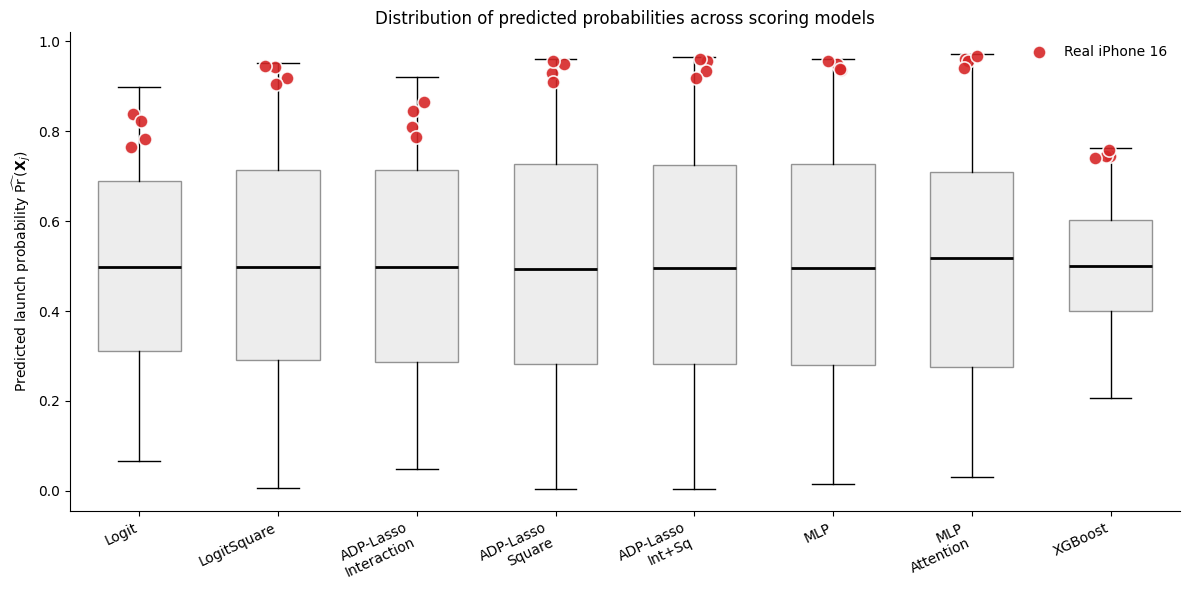

In [6]:
import matplotlib.pyplot as plt

plot_cols = col_probs
plot_data = [df_probm[col].dropna().values for col in plot_cols]

name_map = {
    "iPhone 16": "16 Std",
    "iPhone 16 Plus": "16 Plus",
    "iPhone 16 Pro": "16 Pro",
    "iPhone 16 Pro Max": "16 Pro Max",
}

real_df = df_probm[df_probm["profile_id"].isin(name_map)].copy()
real_df["label"] = real_df["profile_id"].map(name_map)
display_name_map = {
    "pr_Logistic_regression_score": "Logit",
    "pr_LogitSquare": "LogitSquare",
    "pr_adplasso_interaction_thres0.0001": "ADP-Lasso\nInteraction",
    "pr_adplasso_square_thres0.0001": "ADP-Lasso\nSquare",
    "pr_adplasso_interaction_square_thres0.0001": "ADP-Lasso\nInt+Sq",
    "pr_MLP_score": "MLP",
    "pr_MLP_attention_score": "MLP\nAttention",
    "pr_XGBoost": "XGBoost",
}
xpos = np.arange(1, len(plot_cols) + 1)

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(
    plot_data,
    positions=xpos,
    widths=0.6,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set(facecolor="#D3D3D3", alpha=0.4, edgecolor="black")

for median in bp["medians"]:
    median.set(color="black", linewidth=2)

np.random.seed(123)
for i, col in enumerate(plot_cols, start=1):
    x_jitter = i + np.random.normal(0, 0.04, size=len(real_df))
    ax.scatter(
        x_jitter,
        real_df[col],
        s=90,
        color="#D62728",
        edgecolor="white",
        linewidth=1.2,
        alpha=0.9,
        zorder=3,
        label="Real iPhone 16" if i == 1 else None,
    )

ax.set_ylabel(r"Predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$")
ax.set_xticks(xpos)
ax.set_xticklabels([display_name_map.get(col, col.replace("pr_", "")) for col in plot_cols], rotation=25, ha="right")
ax.set_title("Distribution of predicted probabilities across scoring models")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper right", frameon=False) #, bbox_to_anchor=(1.1, 1)

plt.tight_layout()
plt.show()

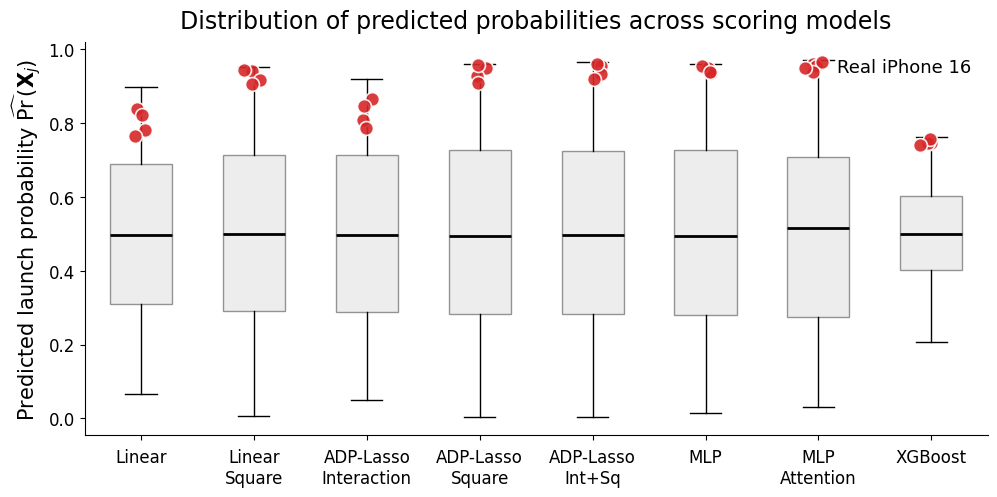

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plot_cols = col_probs
plot_data = [df_probm[col].dropna().values for col in plot_cols]

name_map = {
    "iPhone 16": "16 Std",
    "iPhone 16 Plus": "16 Plus",
    "iPhone 16 Pro": "16 Pro",
    "iPhone 16 Pro Max": "16 Pro Max",
}

real_df = df_probm[df_probm["profile_id"].isin(name_map)].copy()
real_df["label"] = real_df["profile_id"].map(name_map)

display_name_map = {
    "pr_Logistic_regression_score": "Linear",
    "pr_LogitSquare": "Linear\nSquare",
    "pr_adplasso_interaction_thres0.0001": "ADP-Lasso\nInteraction",
    "pr_adplasso_square_thres0.0001": "ADP-Lasso\nSquare",
    "pr_adplasso_interaction_square_thres0.0001": "ADP-Lasso\nInt+Sq",
    "pr_MLP_score": "MLP",
    "pr_MLP_attention_score": "MLP\nAttention",
    "pr_XGBoost": "XGBoost",
}

xpos = np.arange(1, len(plot_cols) + 1)

# Font sizes
title_fs = 17
label_fs = 15
tick_fs = 12
legend_fs = 13

fig, ax = plt.subplots(figsize=(10, 5))

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

bp = ax.boxplot(
    plot_data,
    positions=xpos,
    widths=0.55,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set(facecolor="#D3D3D3", alpha=0.4, edgecolor="black")

for median in bp["medians"]:
    median.set(color="black", linewidth=2)

np.random.seed(123)

for i, col in enumerate(plot_cols, start=1):
    x_jitter = i + np.random.normal(0, 0.035, size=len(real_df))
    ax.scatter(
        x_jitter,
        real_df[col],
        s=100,
        color="#D62728",
        edgecolor="white",
        linewidth=1.2,
        alpha=0.9,
        zorder=3,
        label="Real iPhone 16" if i == 1 else None,
    )

ax.set_ylabel(
    r"Predicted launch probability $\widehat{\Pr}(\mathbf{X}_j)$",
    fontsize=label_fs
)

ax.set_xticks(xpos)
ax.set_xticklabels(
    [display_name_map.get(col, col.replace("pr_", "")) for col in plot_cols],
    rotation=0,
    ha="center",
    fontsize=tick_fs
)

ax.tick_params(axis="y", labelsize=tick_fs)
ax.tick_params(axis="x", pad=6)

ax.set_title(
    "Distribution of predicted probabilities across scoring models",
    fontsize=title_fs,
    pad=10
)

ax.set_xlim(0.5, len(plot_cols) + 0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=legend_fs
)

plt.tight_layout(pad=0.8)

# Optional: save with transparent background
# plt.savefig("predicted_probabilities_boxplot.png", dpi=300, transparent=True, bbox_inches="tight")

plt.show()